In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

COLUMN_NAMES = [
    'checking_status', 'duration', 'credit_history', 'purpose',
    'credit_amount', 'savings_status', 'employment', 'installment_rate',
    'personal_status', 'other_parties', 'residence_since',
    'property_magnitude', 'age', 'other_payment_plans',
    'housing', 'existing_credits', 'job', 'num_dependents',
    'own_telephone', 'foreign_worker', 'class'
]


url = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
       'statlog/german/german.data')
df = pd.read_csv(url, sep=' ', header=None, names=COLUMN_NAMES)

df['class'] = df['class'].map({1: 0, 2: 1})


print(f'Dataset shape : {df.shape}')
print(f'Class balance :\n{df["class"].value_counts(normalize=True).round(3)}')



Dataset shape : (1000, 21)
Class balance :
class
0    0.7
1    0.3
Name: proportion, dtype: float64


In [ ]:
from sklearn.impute import SimpleImputer


TARGET = 'class'
X = df.drop(columns=[TARGET])
y = df[TARGET]


CAT_FEATURES = X.select_dtypes(include='object').columns.tolist()
NUM_FEATURES = X.select_dtypes(include='number').columns.tolist()


print(f'Categorical features ({len(CAT_FEATURES)}): {CAT_FEATURES}')
print(f'Numerical features  ({len(NUM_FEATURES)}): {NUM_FEATURES}')


num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')


X[NUM_FEATURES] = num_imputer.fit_transform(X[NUM_FEATURES])
X[CAT_FEATURES] = cat_imputer.fit_transform(X[CAT_FEATURES])


print(f'Missing values after imputation: {X.isnull().sum().sum()}')


Categorical features (13): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
Numerical features  (7): ['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Missing values after imputation: 0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler, OneHotEncoder
from sklearn.pipeline       import Pipeline
from sklearn.compose        import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline      import Pipeline as ImbPipeline


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                      NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore',
                         sparse_output=False),     CAT_FEATURES),
], remainder='drop')



X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)


ohe_names   = preprocessor.named_transformers_['cat']\
              .get_feature_names_out(CAT_FEATURES).tolist()
FEATURE_NAMES = NUM_FEATURES + ohe_names


smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_enc, y_train)


print(f'Original train class dist: {pd.Series(y_train).value_counts().to_dict()}')
print(f'Resampled train class dist: {pd.Series(y_train_res).value_counts().to_dict()}')


Original train class dist: {0: 560, 1: 240}
Resampled train class dist: {1: 560, 0: 560}


In [ ]:
!pip install optuna
import optuna
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score


optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    """
    Optuna objective function.
    Each 'trial' proposes a set of hyperparameters;
    the function returns the mean 5-fold CV AUC-ROC.
    Optuna maximises this value using a Tree-structured Parzen Estimator (TPE).
    """
    params = {
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.30, log=True),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 0.5, 10.0, log=True),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 0.0, 5.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'objective'         : 'binary:logistic',
        'eval_metric'       : 'auc',
        'use_label_encoder' : False,
        'random_state'      : 42,
        'n_estimators'      : 300,
        'tree_method'       : 'hist'
    }


    model = xgb.XGBClassifier(**params)
    cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    auc_scores = cross_val_score(
        model, X_train_res, y_train_res,
        scoring='roc_auc', cv=cv, n_jobs=-1
    )
    return auc_scores.mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)


print('Best AUC-ROC (CV) :', round(study.best_value, 4))
print('Best parameters   :')
for k, v in study.best_params.items():
    print(f'   {k:25s}: {v}')

  0%|          | 0/50 [00:00<?, ?it/s]

Best AUC-ROC (CV) : 0.919
Best parameters   :
   learning_rate            : 0.040111609502592134
   max_depth                : 8
   reg_lambda               : 0.5894321225814435
   reg_alpha                : 0.39476540746769356
   colsample_bytree         : 0.7307930115032945
   subsample                : 0.9530441952966048
   min_child_weight         : 1


In [ ]:
best_params = study.best_params
best_params.update({
    'objective'         : 'binary:logistic',
    'eval_metric'       : 'auc',
    'use_label_encoder' : False,
    'random_state'      : 42,
    'n_estimators'      : 300,
    'tree_method'       : 'hist'
})

xgb_model = xgb.XGBClassifier(**best_params)
xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test_enc, y_test)],
    verbose=False
)


y_pred_proba = xgb_model.predict_proba(X_test_enc)[:, 1]
y_pred       = xgb_model.predict(X_test_enc)


print('Model training complete.')
print(f'Test set predictions generated for {len(y_pred)} applicants.')


Model training complete.
Test set predictions generated for 200 applicants.


In [ ]:
import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'font.family': 'DejaVu Sans'})


explainer = shap.TreeExplainer(
    xgb_model,
    data=X_train_res,
    feature_perturbation='interventional'
)

shap_values = explainer(X_test_enc)

shap_df = pd.DataFrame(shap_values.values,
                       columns=FEATURE_NAMES)


print(f'SHAP values computed for {shap_df.shape[0]} test samples')
print(f'Feature count: {shap_df.shape[1]}')


SHAP values computed for 200 test samples
Feature count: 61


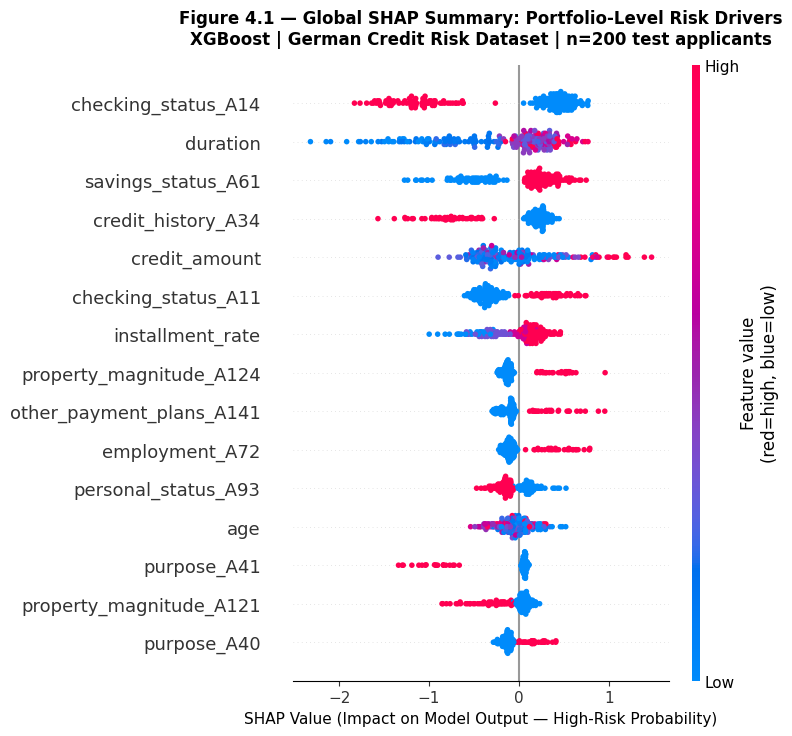


Top 10 Global Risk Drivers (Mean |SHAP| value):
                 Feature  Mean |SHAP|
     checking_status_A14     0.723229
                duration     0.519976
      savings_status_A61     0.388064
      credit_history_A34     0.377477
           credit_amount     0.356877
     checking_status_A11     0.355030
        installment_rate     0.238106
 property_magnitude_A124     0.183167
other_payment_plans_A141     0.168449
          employment_A72     0.162957


In [ ]:
fig_global, ax_global = plt.subplots(figsize=(12, 8))


shap.summary_plot(
    shap_values,
    X_test_enc,
    feature_names=FEATURE_NAMES,
    max_display=15,
    plot_type='dot',
    color_bar_label='Feature value\n(red=high, blue=low)',
    show=False
)


plt.title('Figure 4.1 — Global SHAP Summary: Portfolio-Level Risk Drivers\n'
          'XGBoost | German Credit Risk Dataset | n=200 test applicants',
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('SHAP Value (Impact on Model Output — High-Risk Probability)',
           fontsize=11)
plt.tight_layout()
plt.savefig('fig4_1_global_shap_summary.png', dpi=200, bbox_inches='tight')
plt.show()


mean_abs_shap = pd.DataFrame({
    'Feature'        : FEATURE_NAMES,
    'Mean |SHAP|'    : np.abs(shap_df).mean().values
}).sort_values('Mean |SHAP|', ascending=False).head(10)


print('\nTop 10 Global Risk Drivers (Mean |SHAP| value):')
print(mean_abs_shap.to_string(index=False))


Explaining applicant at test index : 195
True label (1=High-Risk)           : 1
Model predicted probability         : 0.9839


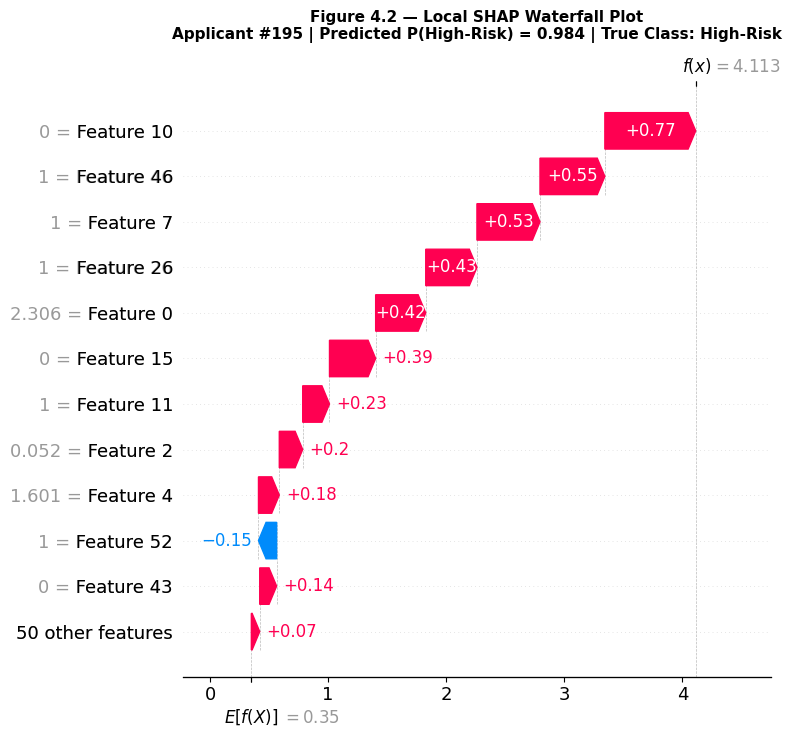


Top risk-increasing features for this applicant:
                Feature  Feature Value  SHAP Contribution
    checking_status_A14       0.000000           0.769460
property_magnitude_A124       1.000000           0.549373
    checking_status_A11       1.000000           0.533889
     savings_status_A61       1.000000           0.433669
               duration       2.305686           0.424120

Top risk-decreasing features for this applicant:
           Feature  Feature Value  SHAP Contribution
own_telephone_A192            0.0          -0.000290
savings_status_A63            0.0          -0.001161
          job_A171            0.0          -0.001225
       purpose_A45            0.0          -0.001379
credit_history_A31            0.0          -0.001826


In [ ]:
high_risk_idx = int(np.argmax(y_pred_proba))


print(f'Explaining applicant at test index : {high_risk_idx}')
print(f'True label (1=High-Risk)           : {y_test.iloc[high_risk_idx]}')
print(f'Model predicted probability         : {y_pred_proba[high_risk_idx]:.4f}')


fig_local, ax_local = plt.subplots(figsize=(12, 7))


shap.plots.waterfall(
    shap_values[high_risk_idx],
    max_display=12,
    show=False
)


plt.title(
    f'Figure 4.2 — Local SHAP Waterfall Plot\n'
    f'Applicant #{high_risk_idx} | Predicted P(High-Risk) = {y_pred_proba[high_risk_idx]:.3f} | True Class: High-Risk',
    fontsize=11, fontweight='bold', pad=12
)
plt.tight_layout()
plt.savefig('fig4_2_local_shap_waterfall.png', dpi=200, bbox_inches='tight')
plt.show()


local_shap = pd.DataFrame({
    'Feature'          : FEATURE_NAMES,
    'Feature Value'    : X_test_enc[high_risk_idx],
    'SHAP Contribution': shap_values[high_risk_idx].values
}).sort_values('SHAP Contribution', ascending=False)


print('\nTop risk-increasing features for this applicant:')
print(local_shap[local_shap['SHAP Contribution'] > 0].head(5).to_string(index=False))
print('\nTop risk-decreasing features for this applicant:')
print(local_shap[local_shap['SHAP Contribution'] < 0].head(5).to_string(index=False))


  EVALUATION REPORT — XGBoost (Tuned) + SMOTE
  AUC-ROC Score            : 0.7802
  Average Precision (AP)   : 0.6512
  Brier Score (Calibration): 0.1737   (lower=better)
  Brier Skill Score        : 0.3052  (higher=better)

  Classification Report (threshold=0.5):
              precision    recall  f1-score   support

    Low-Risk     0.7961    0.8643    0.8288       140
   High-Risk     0.6042    0.4833    0.5370        60

    accuracy                         0.7500       200
   macro avg     0.7001    0.6738    0.6829       200
weighted avg     0.7385    0.7500    0.7412       200



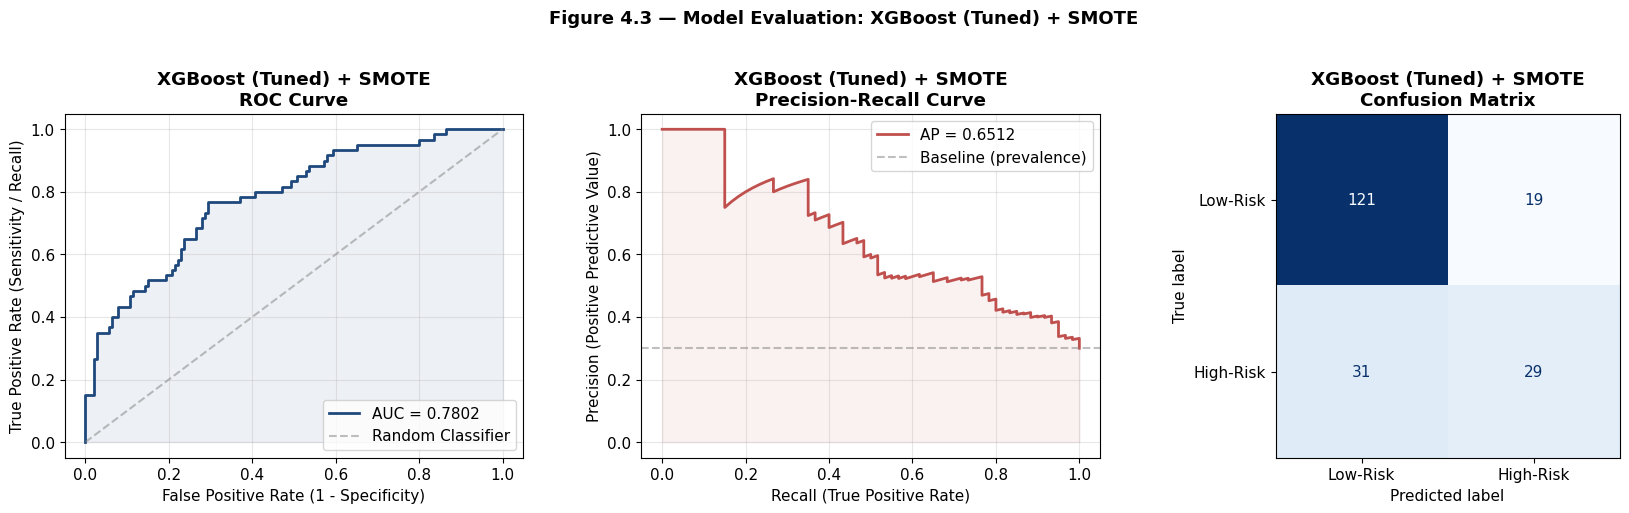

In [ ]:
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    brier_score_loss, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)


def evaluate_risk_model(model_name, y_true, y_proba, y_pred, save_prefix='fig'):
    """
    Produces a full evaluation report for a binary risk classifier.


    Parameters
    ----------
    model_name  : str   — Label used in plot titles and printed output
    y_true      : array — True binary labels (0=Low-Risk, 1=High-Risk)
    y_proba     : array — Predicted probabilities for class 1 (High-Risk)
    y_pred      : array — Binary predicted labels (threshold=0.5)
    save_prefix : str   — Filename prefix for saved figures


    Returns
    -------
    dict containing AUC_ROC, Avg_Precision, Brier_Score
    """
    print('=' * 65)
    print(f'  EVALUATION REPORT — {model_name}')
    print('=' * 65)

    auc_roc = roc_auc_score(y_true, y_proba)
    fpr, tpr, roc_thresh = roc_curve(y_true, y_proba)


    precision, recall, pr_thresh = precision_recall_curve(y_true, y_proba)
    avg_precision = average_precision_score(y_true, y_proba)

    brier = brier_score_loss(y_true, y_proba)

    print(f'  AUC-ROC Score            : {auc_roc:.4f}')
    print(f'  Average Precision (AP)   : {avg_precision:.4f}')
    print(f'  Brier Score (Calibration): {brier:.4f}   (lower=better)')
    print(f'  Brier Skill Score        : {1 - brier/0.25:.4f}  (higher=better)')
    print()
    print('  Classification Report (threshold=0.5):')
    print(classification_report(y_true, y_pred,
                               target_names=['Low-Risk','High-Risk'],
                               digits=4))

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))


    axes[0].plot(fpr, tpr, lw=2, color='#1F497D',
                 label=f'AUC = {auc_roc:.4f}')
    axes[0].plot([0, 1], [0, 1], '--', color='grey', alpha=0.5,
                 label='Random Classifier')
    axes[0].fill_between(fpr, tpr, alpha=0.08, color='#1F497D')
    axes[0].set_title(f'{model_name}\nROC Curve', fontweight='bold')
    axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
    axes[0].set_ylabel('True Positive Rate (Sensitivity / Recall)')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)


    axes[1].plot(recall, precision, lw=2, color='#C0504D',
                 label=f'AP = {avg_precision:.4f}')
    axes[1].axhline(y=sum(y_true)/len(y_true), linestyle='--',
                    color='grey', alpha=0.5, label='Baseline (prevalence)')
    axes[1].fill_between(recall, precision, alpha=0.08, color='#C0504D')
    axes[1].set_title(f'{model_name}\nPrecision-Recall Curve', fontweight='bold')
    axes[1].set_xlabel('Recall (True Positive Rate)')
    axes[1].set_ylabel('Precision (Positive Predictive Value)')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    cm_arr = confusion_matrix(y_true, y_pred)
    disp   = ConfusionMatrixDisplay(cm_arr,
               display_labels=['Low-Risk', 'High-Risk'])
    disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
    axes[2].set_title(f'{model_name}\nConfusion Matrix', fontweight='bold')


    plt.suptitle(f'Figure 4.3 — Model Evaluation: {model_name}',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_evaluation.png', dpi=200, bbox_inches='tight')
    plt.show()


    return {'AUC_ROC': round(auc_roc, 4),
            'Avg_Precision': round(avg_precision, 4),
            'Brier_Score': round(brier, 4)}


xgb_metrics = evaluate_risk_model(
    model_name   = 'XGBoost (Tuned) + SMOTE',
    y_true       = y_test,
    y_proba      = y_pred_proba,
    y_pred       = y_pred,
    save_prefix  = 'fig4_3'
)
